In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

import scipy.cluster.hierarchy as sch

In [2]:
df = pd.read_csv("Credit Card Customer Data.csv")

df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [3]:
df.shape

(660, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [5]:
df.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,330.500000,55141.443939,34574.242424,4.706061,2.403030,2.606061,3.583333
std,190.669872,25627.772200,37625.487804,2.167835,1.631813,2.935724,2.865317
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,165.750000,33825.250000,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,330.500000,53874.500000,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,495.250000,77202.500000,48000.000000,6.000000,4.000000,4.000000,5.000000
max,660.000000,99843.000000,200000.000000,10.000000,5.000000,15.000000,10.000000


In [6]:
df.isnull().sum()

Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

In [7]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [14]:
df.drop(columns=["Sl_No"], inplace=True)
df.drop(columns=["Customer Key"], inplace=True)

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

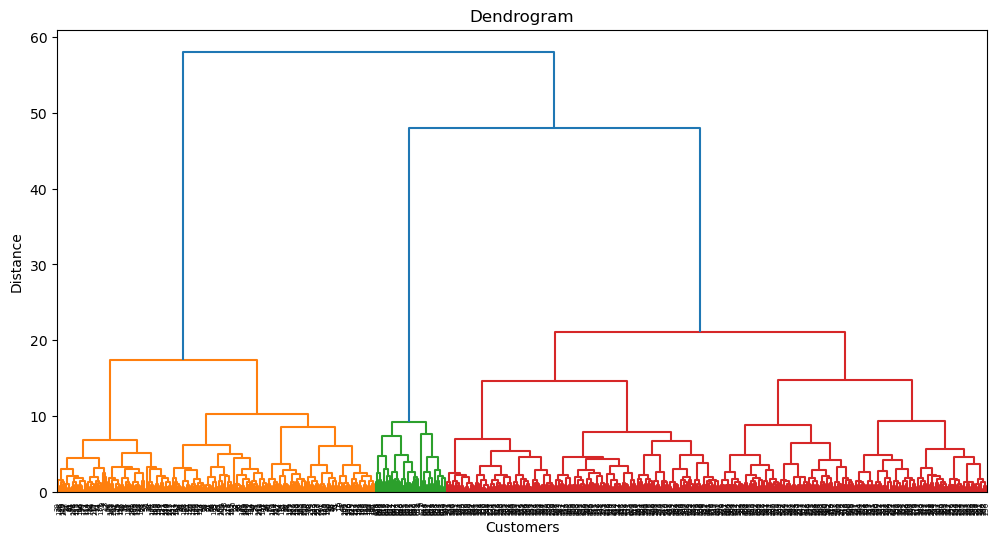

In [10]:
plt.figure(figsize=(12,6))

sch.dendrogram(sch.linkage(X_scaled[:1000], method='ward'))

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [11]:
model = AgglomerativeClustering(n_clusters=5, linkage='ward')

labels = model.fit_predict(X_scaled)

In [15]:
df["Cluster"] = labels

df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Cluster
0,100000,2,1,1,0,3
1,50000,3,0,10,9,4
2,50000,7,1,3,4,4
3,30000,5,1,1,4,4
4,100000,6,0,12,3,2


In [16]:
df["Cluster"].value_counts()

Cluster
1    194
0    190
3    145
4     81
2     50
Name: count, dtype: int64

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

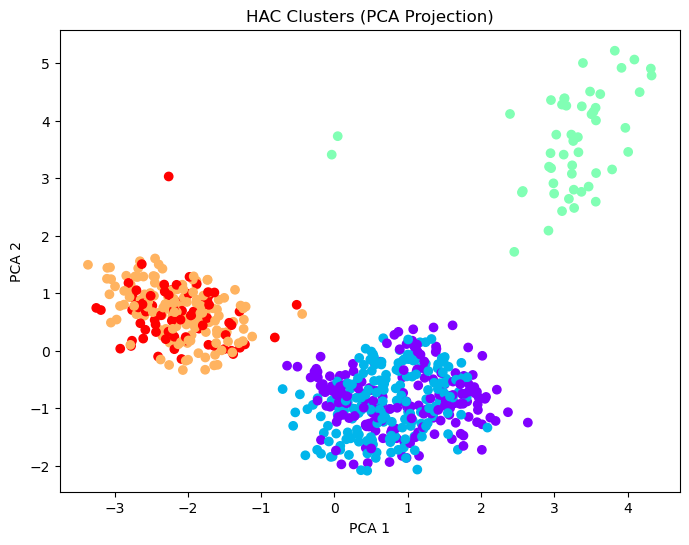

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='rainbow')

plt.title("HAC Clusters (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [19]:
cluster_summary = df.groupby("Cluster").mean()

cluster_summary

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,31873.684211,5.726316,3.521053,1.063158,1.852632
1,35108.247423,5.314433,3.489691,0.896907,2.144330
2,141040.000000,8.740000,0.600000,10.900000,1.080000
3,12717.241379,2.331034,0.889655,3.441379,6.813793
4,13037.037037,2.617284,1.000000,3.703704,6.851852


In [20]:
score = silhouette_score(X_scaled, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.22640138782907812
